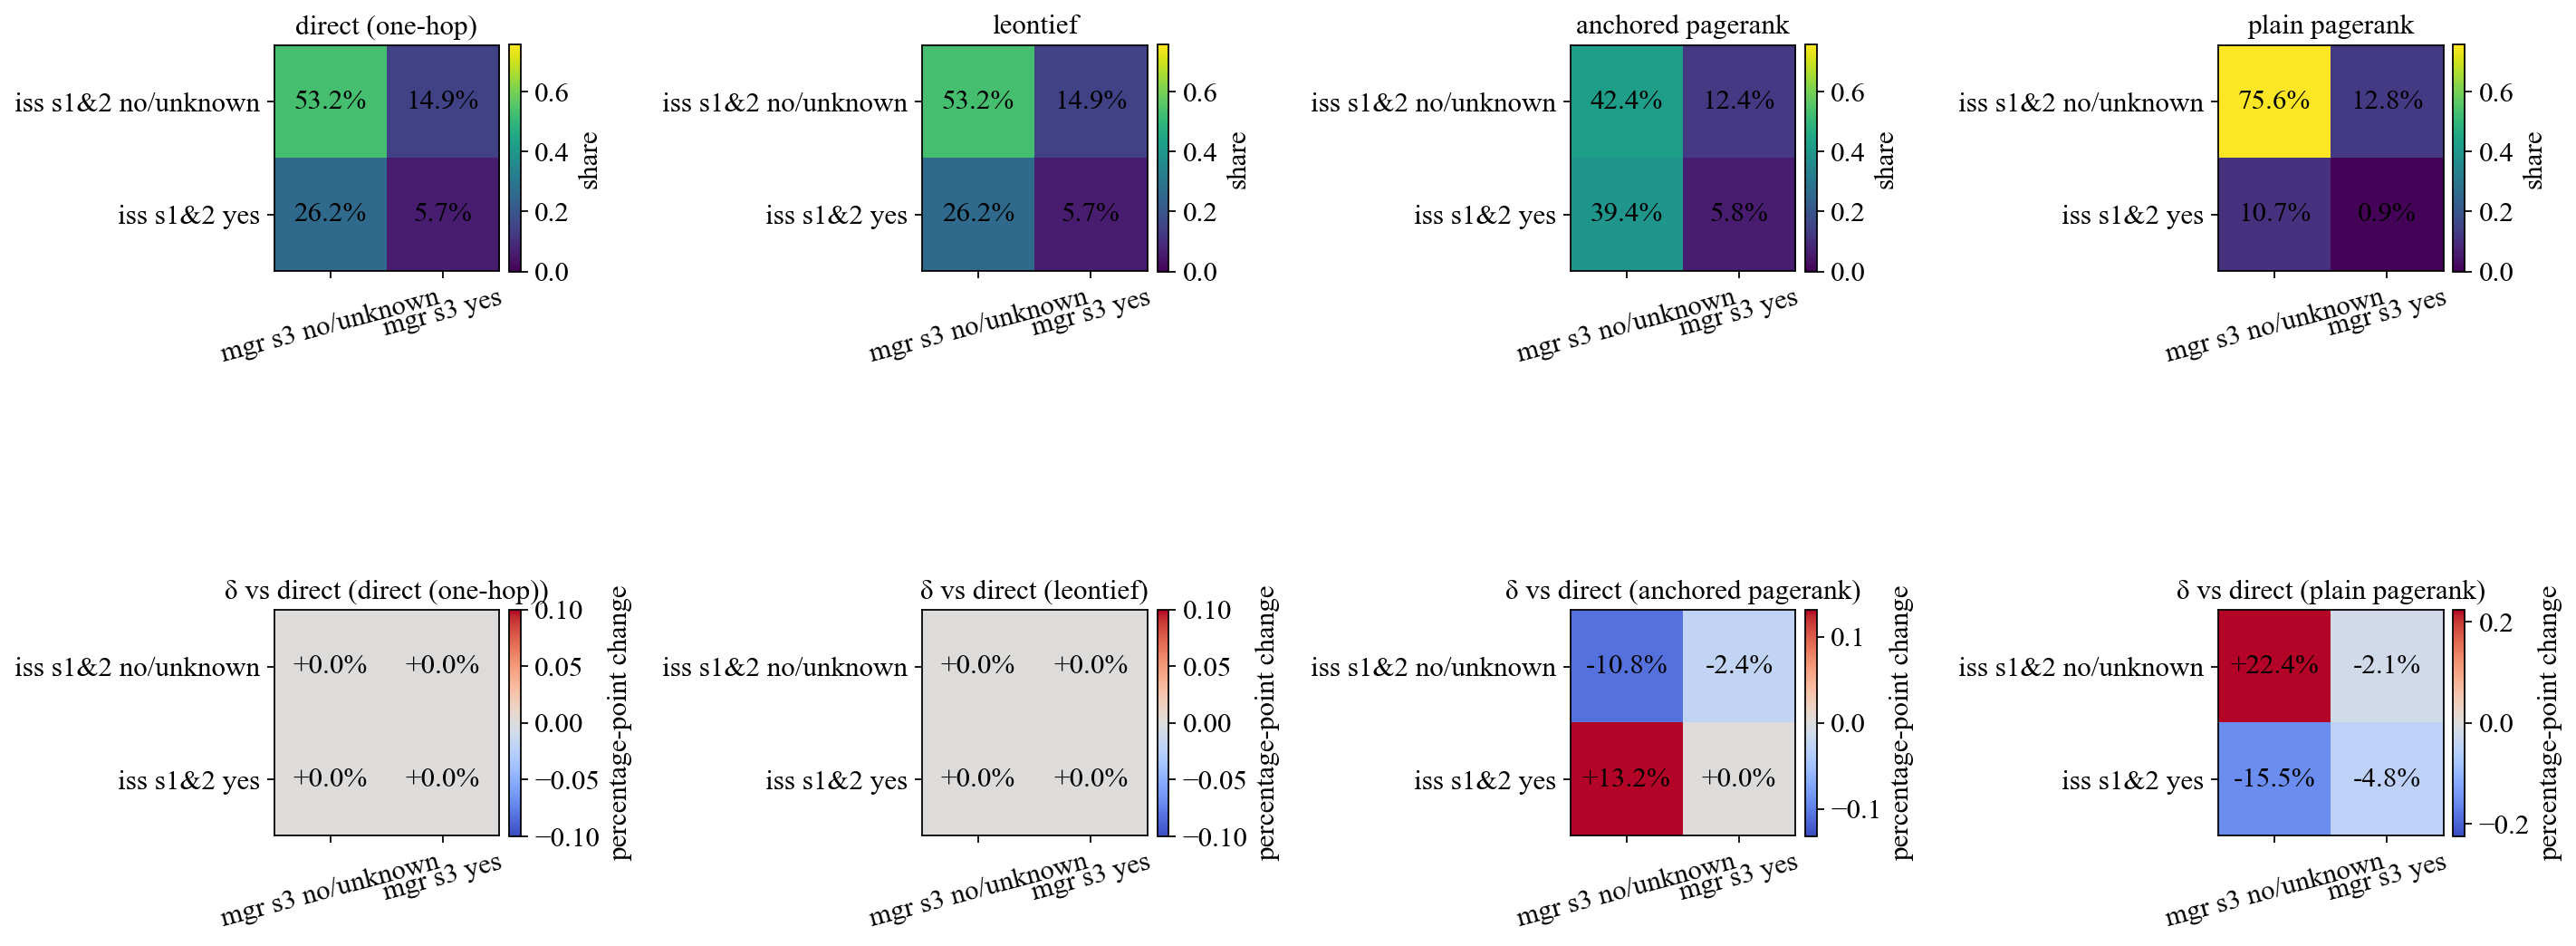

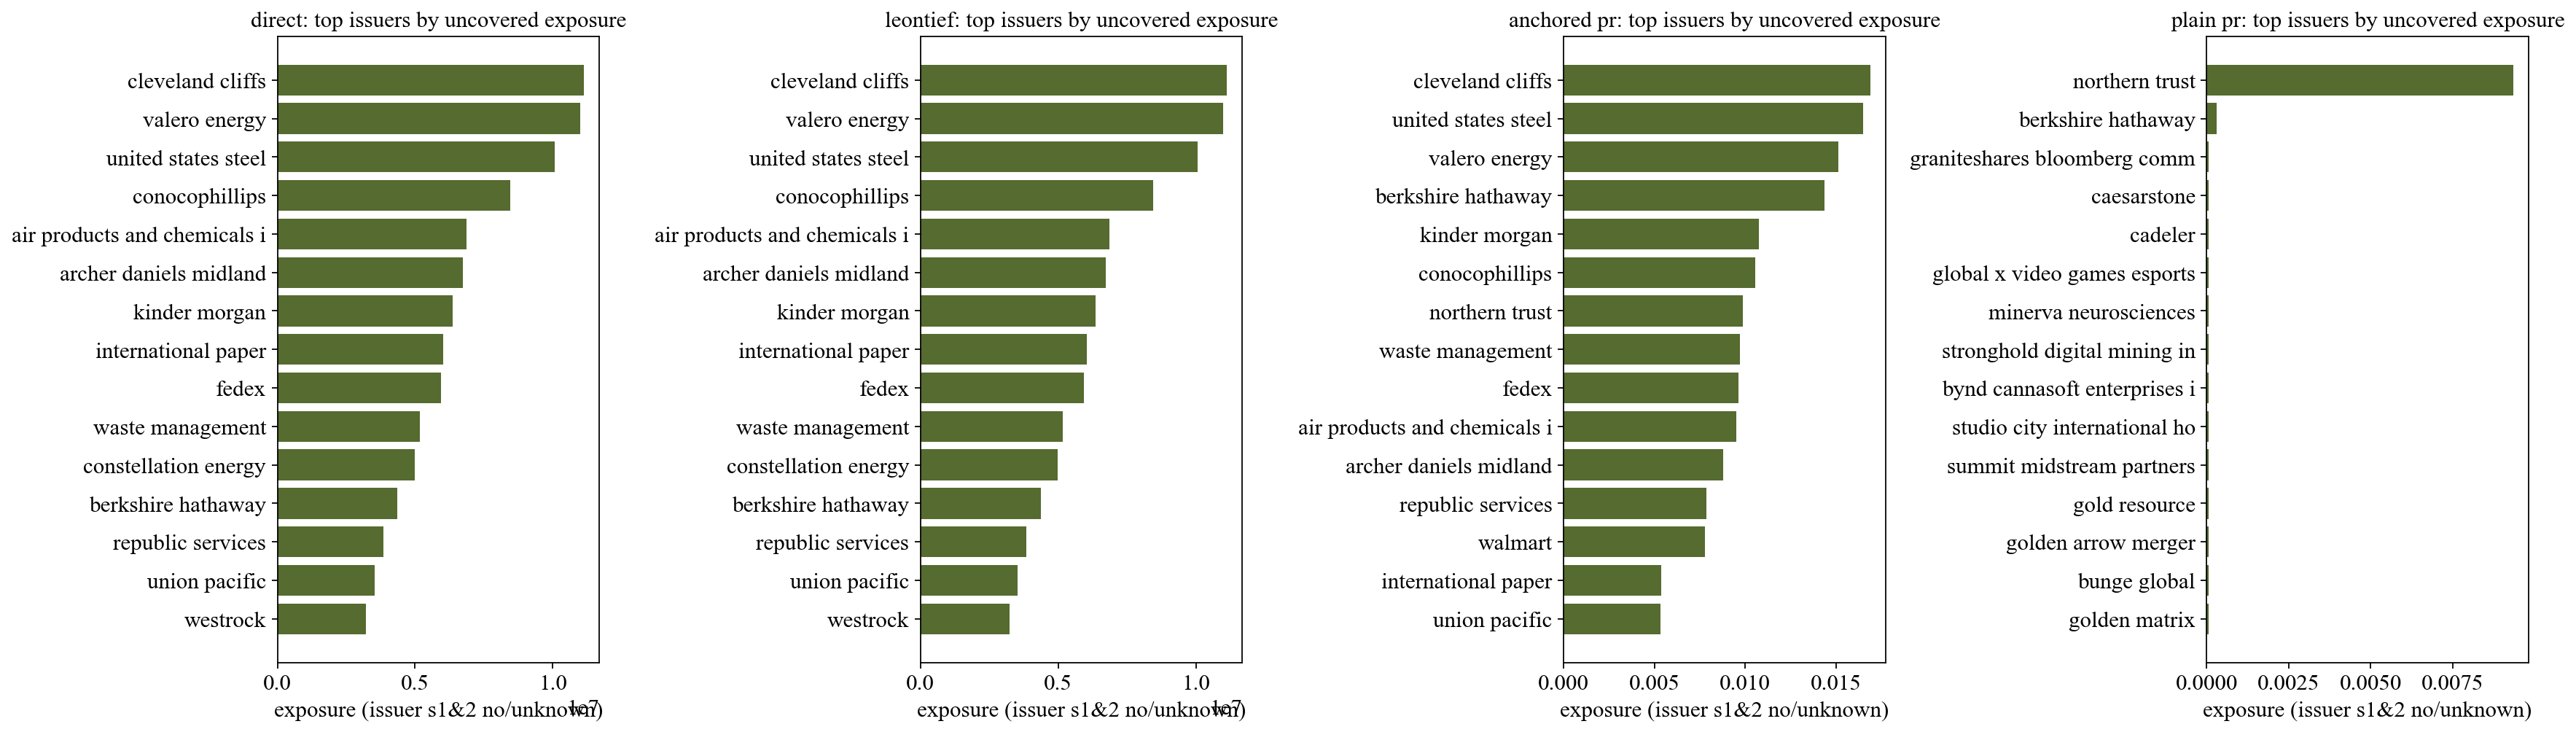

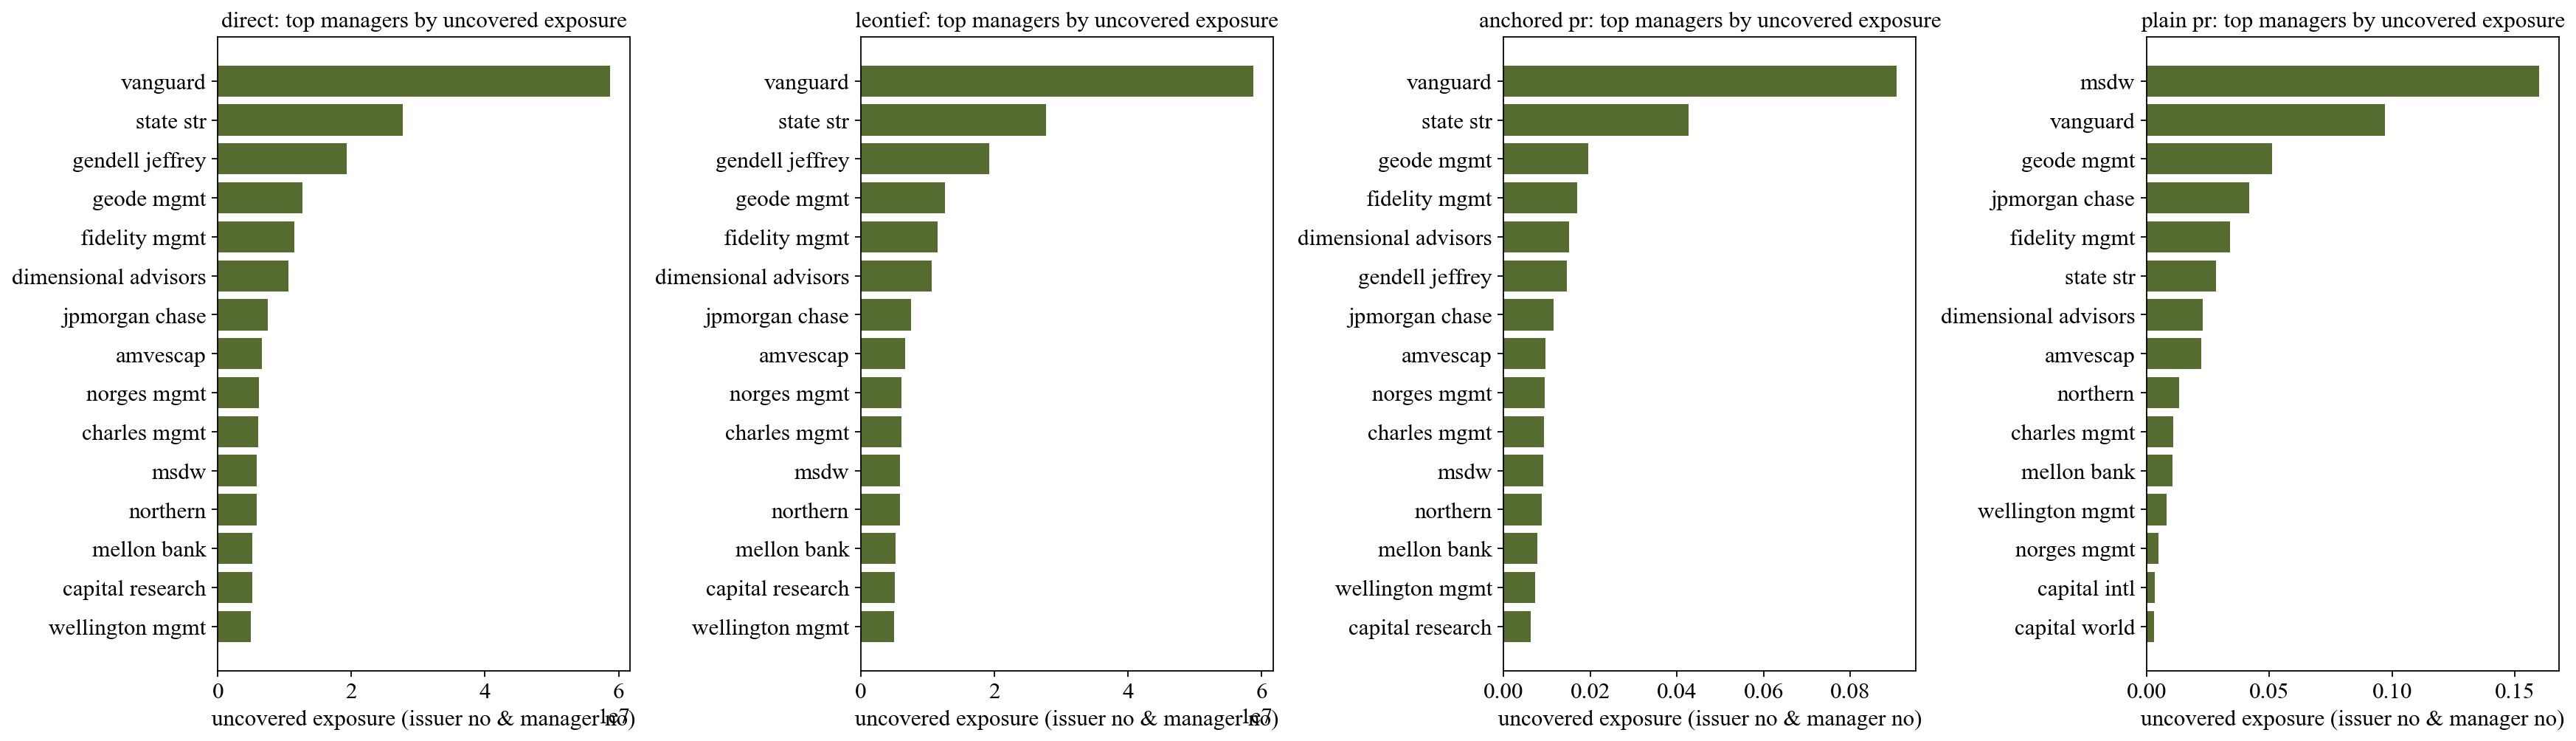

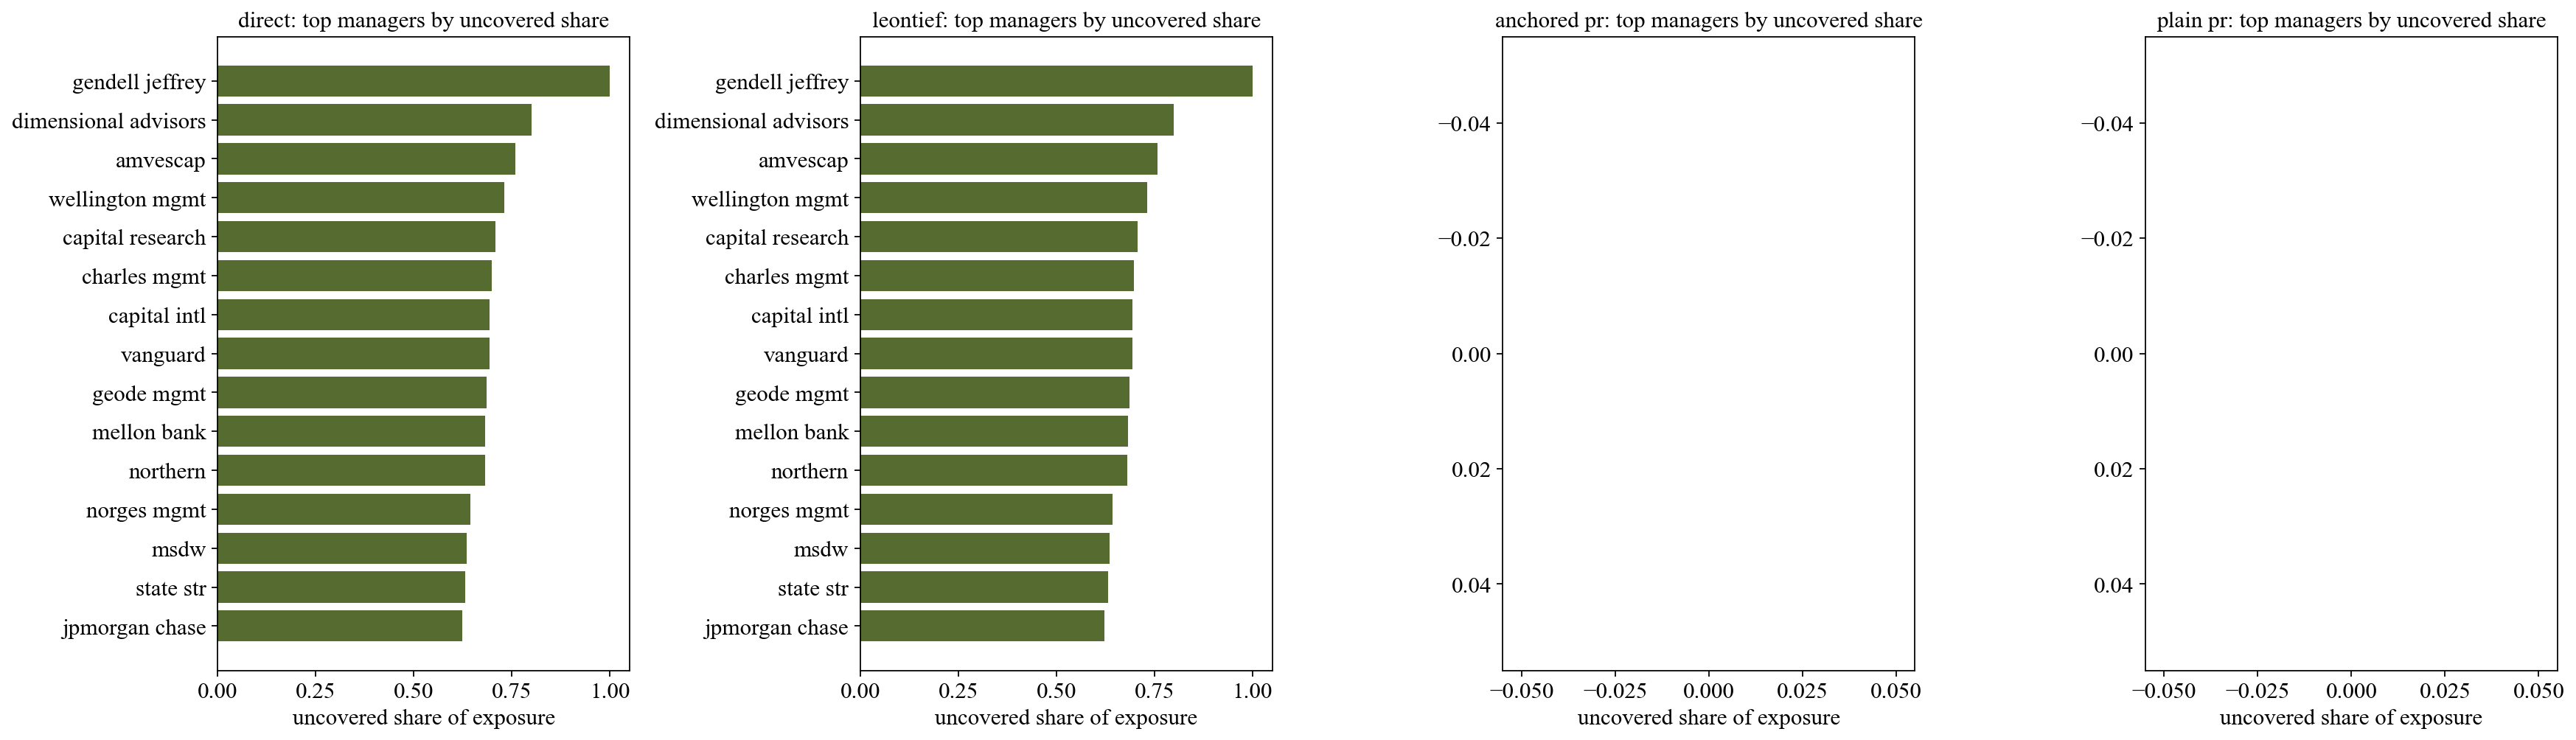

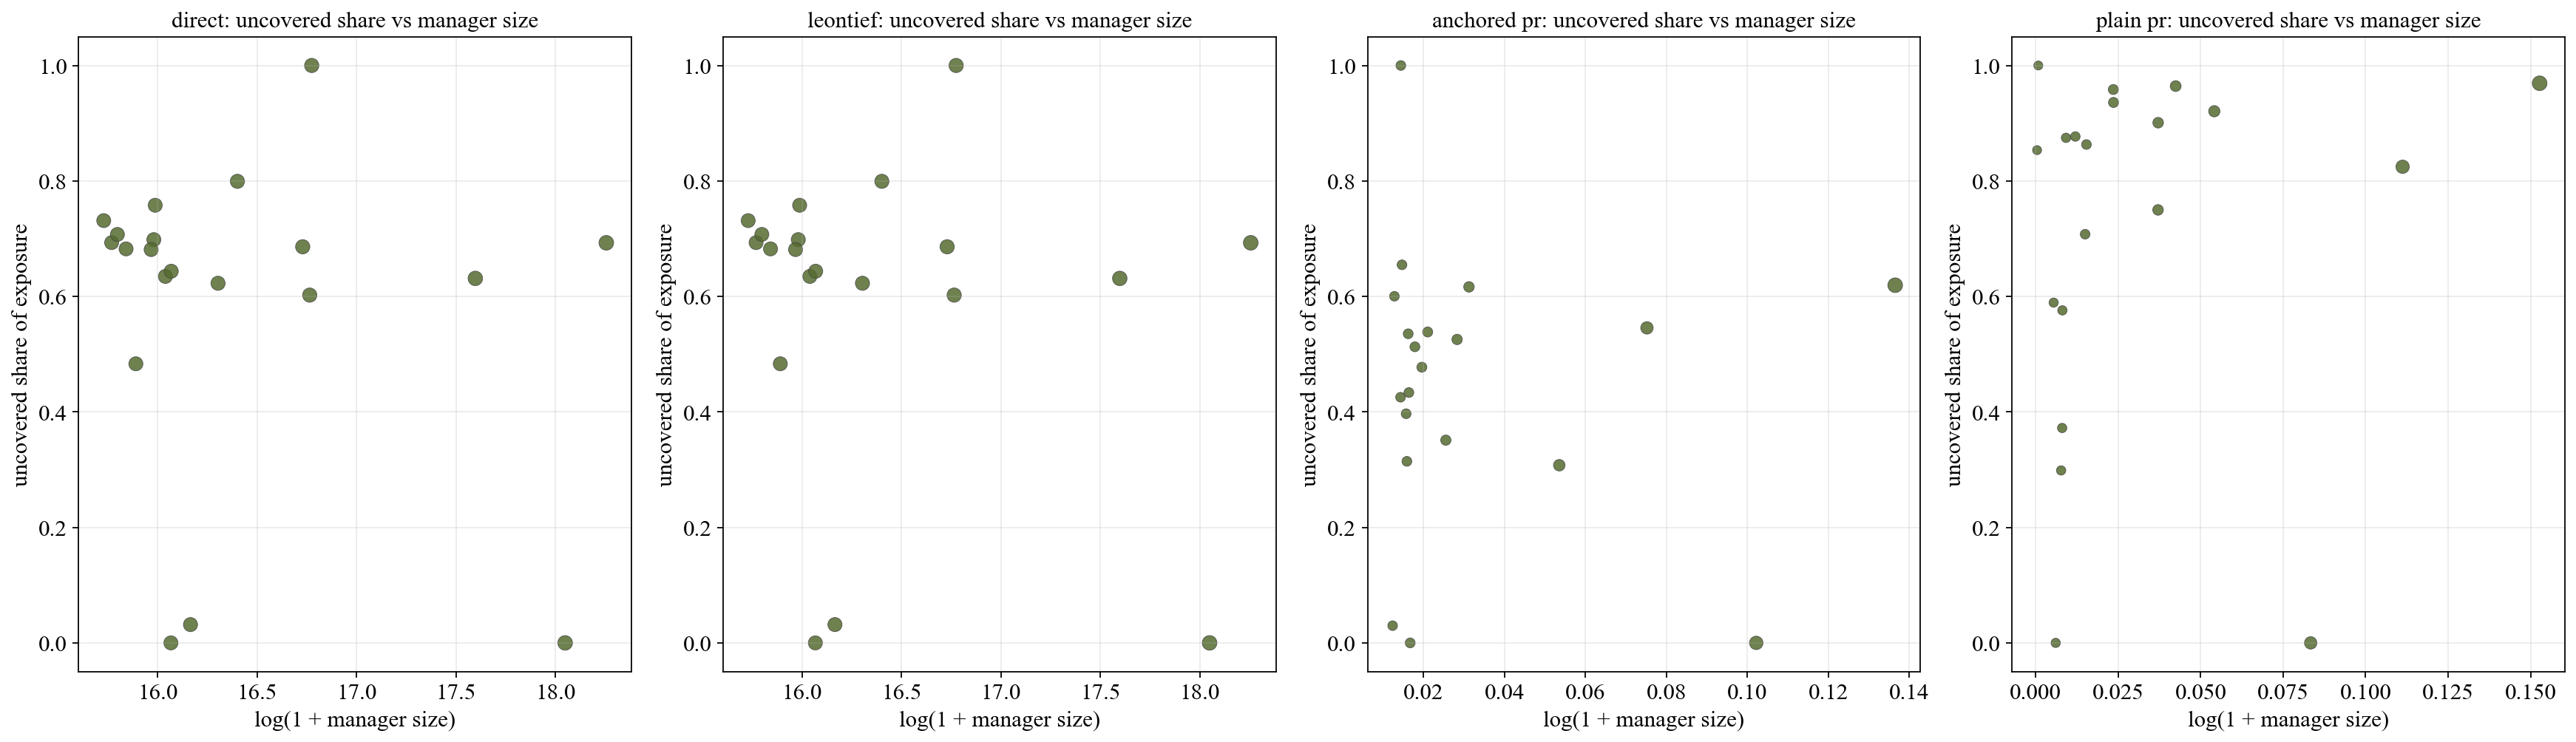


Direct:
  iss s1&2 no/unknown    |   53.2%    14.9%
  iss s1&2 yes           |   26.2%     5.7%

Leontief:
  iss s1&2 no/unknown    |   53.2%    14.9%
  iss s1&2 yes           |   26.2%     5.7%

Anchored PageRank:
  iss s1&2 no/unknown    |   42.4%    12.4%
  iss s1&2 yes           |   39.4%     5.8%

Plain PageRank:
  iss s1&2 no/unknown    |   75.6%    12.8%
  iss s1&2 yes           |   10.7%     0.9%

Δ vs Direct — Leontief:
  iss s1&2 no/unknown    |   +0.0pp    +0.0pp
  iss s1&2 yes           |   +0.0pp    +0.0pp

Δ vs Direct — Anchored PageRank:
  iss s1&2 no/unknown    |  -10.8pp    -2.4pp
  iss s1&2 yes           |  +13.2pp    +0.0pp

Δ vs Direct — Plain PageRank:
  iss s1&2 no/unknown    |  +22.4pp    -2.1pp
  iss s1&2 yes           |  -15.5pp    -4.8pp


In [2]:
# ============================================
# Pledge Coverage – Clean, commented notebook
# ============================================

import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl, networkx as nx, re

# ---------- global style ----------
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

# ---------- paths & switches ----------
NODES_CSV    = "outputs/pledges_overlay/nodes_top20_leontief_with_pledges.csv"
EDGES_CSV    = "outputs/pledges_overlay/edges_top20_leontief_with_pledges.csv"
PLEDGES_XLSX = "Basic pledges analysis.xlsx"     # columns: LSEG, NZT, Scope 1, Scope 2, Scope 3
PARTIAL_COUNTS_AS_YES = False                    # treat "partial" targets as covered?
LEONTIEF_COL = None                               # set to per-edge Leontief flow column if you have one

# ----------- helpers -----------
def _norm_name(s: str) -> str:
    s = "" if s is None else str(s)
    s = s.lower().replace("&"," and ")
    s = re.sub(r"\([^)]*\)", " ", s)
    s = re.sub(r"[^\w\s\-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

_DROP_TOKENS = {
    "inc","incorporated","plc","ltd","llc","lp","llp","corp","corporation","co","company","sa","spa","s p a",
    "srl","nv","bv","ag","kgaa","gmbh","pte","limited","holdings","holding","group","partners","trust",
    "class","cl","ord","adr","a","b","c","d","e","f","g","h","i","ii","iii","iv","v","vi","vii","viii","ix","x",
    "london","new","york","ny","usa","uk","us","eu","ireland","ire","france","germany","de","it","italy"
}
def short_label(name, max_words=2):
    s = "" if name is None else str(name).lower()
    s = re.sub(r"^idelity\b", "fidelity", s)
    s = re.sub(r"\([^)]*\)", " ", s)
    s = re.sub(r"[^\w\s\-]", " ", s)
    s = re.sub(r"\d+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = s.replace("management","mgmt").replace("investment management","inv mgmt").replace(" and "," ")
    s = s.replace(" fd ", " ").replace("and research","")
    toks = [t for t in s.split() if t not in _DROP_TOKENS and len(t) > 1]
    if not toks: return ""
    if "mgmt" in toks:      return f"{toks[0]} mgmt"
    if "advisors" in toks:  return f"{toks[0]} advisors"
    return " ".join(toks[:max_words])

def _flag_from_cell(x, partial_val=0.5):
    s = str(x).strip().lower()
    if s in {"yes","y","true","1"}:   return 1.0
    if s in {"no","n","false","0"}:   return 0.0
    if s in {"partial","part","partly"}:
        return 1.0 if PARTIAL_COUNTS_AS_YES else partial_val
    if s in {"", "nan", "not specified", "#n/a", "n/a", "none"}: return 0.0
    try: return 1.0 if float(s) >= 1.0 else 0.0
    except: return 0.0

def load_pledges_exact(xlsx):
    df = pd.read_excel(xlsx, sheet_name=0, dtype=str)
    required = ["LSEG","Scope 1","Scope 2","Scope 3"]
    miss = [c for c in required if c not in df.columns]
    if miss: raise KeyError(f"Missing columns in pledges file: {miss}")
    out = pd.DataFrame({
        "node": df["LSEG"].map(_norm_name),
        "s1": df["Scope 1"].map(_flag_from_cell),
        "s2": df["Scope 2"].map(_flag_from_cell),
        "s3": df["Scope 3"].map(_flag_from_cell),
        "framework": df["NZT"] if "NZT" in df.columns else ""
    }).drop_duplicates("node", keep="last")
    return out

def coverage_matrix(df, wcol, ic_col="_issuer_cov", mc_col="_manager_cov"):
    w = df[wcol].astype(float).clip(lower=0)
    tot = float(w.sum()) + 1e-12
    M = np.zeros((2,2), dtype=float)
    for i in (0,1):
        for j in (0,1):
            M[i,j] = float(w[(df[ic_col]==i) & (df[mc_col]==j)].sum()) / tot
    return M

def plot_cov_heatmap(M, title, ax=None, vmax=None, cmap="viridis"):
    ax = plt.gca() if ax is None else ax
    vmax = float(M.max()) if vmax is None else vmax
    im = ax.imshow(M, vmin=0, vmax=vmax, cmap=cmap)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{M[i,j]*100:.1f}%", ha="center", va="center", color="black")
    ax.set_xticks([0,1]); ax.set_xticklabels(["mgr s3 no/unknown".lower(), "mgr s3 yes".lower()], rotation=15)
    ax.set_yticks([0,1]); ax.set_yticklabels(["iss s1&2 no/unknown".lower(), "iss s1&2 yes".lower()])
    ax.set_title(title.lower())
    return im

# ---------- 1) LOAD + PREPARE ----------
nodes = pd.read_csv(NODES_CSV)
edges = pd.read_csv(EDGES_CSV)

edges["issuer_norm"]  = edges["issuer"].map(_norm_name)
edges["manager_norm"] = edges["manager"].map(_norm_name)
edges["ws"] = edges["weight"].astype(float) * edges["s12"].astype(float)    # direct exposure

if "yL_tCO2" in nodes.columns:
    mgr_size_leo = (nodes[nodes["role"].str.lower().eq("manager")]
                    .set_index("node")["yL_tCO2"].astype(float))
else:
    mgr_size_leo = edges.groupby("manager")["ws"].sum()

pl = load_pledges_exact(PLEDGES_XLSX).set_index("node")
issuer_cov = ((pl.reindex(edges["issuer_norm"])["s1"] >= 1.0) &
              (pl.reindex(edges["issuer_norm"])["s2"] >= 1.0)).fillna(False)
manager_cov = (pl.reindex(edges["manager_norm"])["s3"] >= 1.0).fillna(False)
edges["_issuer_cov"]  = issuer_cov.astype(int).to_numpy()
edges["_manager_cov"] = manager_cov.astype(int).to_numpy()
edges["_neither"]     = ((edges["_issuer_cov"]==0) & (edges["_manager_cov"]==0)).astype(int)

iss_s12 = edges.groupby("issuer")["s12"].max()
G = nx.DiGraph()
for _, r in edges.iterrows():
    G.add_edge(str(r["issuer"]).lower(), str(r["manager"]).lower(), w=float(r["weight"]))

edges_lc = edges[["issuer","manager","weight","_issuer_cov","_manager_cov"]].copy()
edges_lc["issuer"]  = edges_lc["issuer"].str.lower()
edges_lc["manager"] = edges_lc["manager"].str.lower()
row_sum = edges_lc.groupby("issuer")["weight"].sum()
Pij_base = edges_lc.copy()
Pij_base["prob"] = Pij_base["weight"] / row_sum.reindex(Pij_base["issuer"]).values

def make_pr_flow(personalization_dict, alpha=0.60):
    pr = nx.pagerank(G, alpha=alpha, personalization=personalization_dict,
                     dangling=personalization_dict, weight='w')
    P = Pij_base.copy()
    P["pr_flow"] = P["issuer"].map(pr).astype(float) * P["prob"].astype(float)
    P["_issuer_cov"]  = edges["_issuer_cov"].values
    P["_manager_cov"] = edges["_manager_cov"].values
    return P

iss_s12_lc = iss_s12.copy(); iss_s12_lc.index = iss_s12_lc.index.str.lower()
p_apr = {n: float(iss_s12_lc.get(n, 0.0)) for n in G.nodes()}
S = sum(p_apr.values()) or 1.0
p_apr = {n: (v/S) for n, v in p_apr.items()}
Pij_apr = make_pr_flow(p_apr, alpha=0.60)

issuer_nodes = set(edges_lc["issuer"].unique())
p_plain = {n: (1.0/len(issuer_nodes) if n in issuer_nodes else 0.0) for n in G.nodes()}
Pij_pr  = make_pr_flow(p_plain, alpha=0.60)

# ---------- 2) HEAT MAPS ----------
edges["w_direct"]   = edges["ws"].astype(float)
edges["w_leontief"] = (edges[LEONTIEF_COL].astype(float)
                       if (LEONTIEF_COL and LEONTIEF_COL in edges.columns)
                       else edges["w_direct"])

mat_direct   = coverage_matrix(edges,  "w_direct")
mat_leontief = coverage_matrix(edges,  "w_leontief")
mat_apr      = coverage_matrix(Pij_apr, "pr_flow")
mat_pr       = coverage_matrix(Pij_pr,  "pr_flow")

fig, axs = plt.subplots(2, 4, figsize=(18, 8), dpi=160)
allM   = [mat_direct, mat_leontief, mat_apr, mat_pr]
titles = ["direct (one-hop)", "leontief", "anchored pagerank", "plain pagerank"]
vmax   = max(M.max() for M in allM)

ims = []
for k, M in enumerate(allM):
    ims.append(plot_cov_heatmap(M, titles[k], ax=axs[0, k], vmax=vmax))

for k, M in enumerate(allM):
    diff = M - mat_direct
    v = np.max(np.abs(diff))
    im = axs[1, k].imshow(diff, vmin=-v, vmax=v, cmap="coolwarm")
    for i in range(2):
        for j in range(2):
            axs[1, k].text(j, i, f"{diff[i,j]*100:+.1f}%", ha="center", va="center", color="black")
    axs[1, k].set_xticks([0,1]); axs[1, k].set_xticklabels(["mgr s3 no/unknown".lower(), "mgr s3 yes".lower()], rotation=15)
    axs[1, k].set_yticks([0,1]); axs[1, k].set_yticklabels(["iss s1&2 no/unknown".lower(), "iss s1&2 yes".lower()])
    axs[1, k].set_title(f"Δ vs direct ({titles[k]})".lower())
    ims.append(im)

for k in range(4):   plt.colorbar(ims[k],   ax=axs[0, k], fraction=0.046, pad=0.04).set_label("share".lower())
for k in range(4,8): plt.colorbar(ims[k], ax=axs[1, k-4], fraction=0.046, pad=0.04).set_label("percentage-point change".lower())
plt.tight_layout(); plt.show()

# ---------- 3) RANKINGS (issuers & managers) ----------
def edges_for_method(method: str):
    if method == "direct":
        df = edges[["issuer","manager","w_direct","_issuer_cov","_manager_cov"]].rename(columns={"w_direct":"w"}).copy()
    elif method == "leontief":
        df = edges[["issuer","manager","w_leontief","_issuer_cov","_manager_cov"]].rename(columns={"w_leontief":"w"}).copy()
    elif method == "apr":
        df = Pij_apr[["issuer","manager","pr_flow","_issuer_cov","_manager_cov"]].rename(columns={"pr_flow":"w"}).copy()
    elif method == "pr":
        df = Pij_pr[["issuer","manager","pr_flow","_issuer_cov","_manager_cov"]].rename(columns={"pr_flow":"w"}).copy()
    else:
        raise ValueError("unknown method")
    df["_neither"] = ((df["_issuer_cov"]==0) & (df["_manager_cov"]==0)).astype(int)
    return df

METHODS = [("direct","Direct"), ("leontief","Leontief"), ("apr","Anchored PR"), ("pr","Plain PR")]

# (a) Top issuers by uncovered exposure — EXCLUDE IES
EXCLUDE_ISSUERS_RAW  = {"IES"}     # <-- remove this raw name from issuer bars
EXCLUDE_ISSUERS_NORM = {"ies"}     # <-- and its normalized form

fig, axs = plt.subplots(1, 4, figsize=(22, 6.5), dpi=160)
for ax, (key, title) in zip(axs, METHODS):
    df = edges_for_method(key)
    tmp = pd.DataFrame({
        "issuer": df["issuer"],
        "issuer_norm": df["issuer"].map(_norm_name),
        "w": df["w"],
        "_issuer_cov": df["_issuer_cov"]
    })
    mask = (~tmp["issuer"].astype(str).str.strip().isin(EXCLUDE_ISSUERS_RAW) &
            ~tmp["issuer_norm"].isin(EXCLUDE_ISSUERS_NORM) &
             (tmp["_issuer_cov"]==0))
    top = (tmp.loc[mask].groupby("issuer")["w"].sum()
           .sort_values(ascending=False).head(15))

    ax.barh([s.lower() for s in top.index], top.values, color="darkolivegreen")
    ax.invert_yaxis()
    ax.set_title(f"{title}: top issuers by uncovered exposure".lower())
    ax.set_xlabel("exposure (issuer s1&2 no/unknown)".lower())

plt.tight_layout(); plt.show()

# (b) Top managers by uncovered exposure
fig, axs = plt.subplots(1, 4, figsize=(22, 6.5), dpi=160)
for ax, (key, title) in zip(axs, METHODS):
    df = edges_for_method(key)
    top = (df.loc[df["_neither"]==1].groupby("manager")["w"].sum()
           .sort_values(ascending=False).head(15))
    ax.barh([short_label(m) for m in top.index], top.values, color="darkolivegreen")
    ax.invert_yaxis()
    ax.set_title(f"{title}: top managers by uncovered exposure".lower())
    ax.set_xlabel("uncovered exposure (issuer no & manager no)".lower())

plt.tight_layout(); plt.show()

# (c) Top managers by uncovered share (floor)
MIN_TOT = 1e6
fig, axs = plt.subplots(1, 4, figsize=(22, 6.5), dpi=160)
for ax, (key, title) in zip(axs, METHODS):
    df = edges_for_method(key)
    tot = df.groupby("manager")["w"].sum()
    unc = df.loc[df["_neither"]==1].groupby("manager")["w"].sum()
    share = (unc / tot).dropna()
    share = share[tot.reindex(share.index) >= MIN_TOT].sort_values(ascending=False).head(15)
    ax.barh([short_label(m) for m in share.index], share.values, color="darkolivegreen")
    ax.invert_yaxis()
    ax.set_title(f"{title}: top managers by uncovered share".lower())
    ax.set_xlabel("uncovered share of exposure".lower())

plt.tight_layout(); plt.show()

# ---------- 4) SCATTER: uncovered share vs manager size ----------
fig, axs = plt.subplots(1, 4, figsize=(22, 6.5), dpi=160)
for ax, (key, title) in zip(axs, METHODS):
    df = edges_for_method(key)
    size = df.groupby("manager")["w"].sum()
    unc  = df.loc[df["_neither"]==1].groupby("manager")["w"].sum()
    share = (unc / size).reindex(size.index).fillna(0.0)

    x = np.log1p(size.values)
    y = share.values
    s = 30 + 50 * (np.log1p(size.values)/(np.log1p(size.values).max()+1e-9))

    ax.scatter(x, y, s=s, alpha=0.85, color="darkolivegreen", edgecolors="#444", linewidths=0.4)
    ax.set_title(f"{title}: uncovered share vs manager size".lower())
    ax.set_xlabel("log(1 + manager size)".lower())
    ax.set_ylabel("uncovered share of exposure".lower())
    ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

# ---------- 5) Console summary ----------
row_lab = ["iss s1&2 no/unknown", "iss s1&2 yes"]
def _print_matrix(M, name):
    print(f"\n{name}:")
    for i in range(2):
        print(f"  {row_lab[i]:<22} |  {M[i,0]*100:5.1f}%   {M[i,1]*100:5.1f}%")
def _print_delta(M, base, name):
    print(f"\nΔ vs Direct — {name}:")
    for i in range(2):
        print(f"  {row_lab[i]:<22} |  {(M[i,0]-base[i,0])*100:+5.1f}pp   {(M[i,1]-base[i,1])*100:+5.1f}pp")

_print_matrix(mat_direct,   "Direct")
_print_matrix(mat_leontief, "Leontief")
_print_matrix(mat_apr,      "Anchored PageRank")
_print_matrix(mat_pr,       "Plain PageRank")
_print_delta(mat_leontief,  mat_direct, "Leontief")
_print_delta(mat_apr,       mat_direct, "Anchored PageRank")
_print_delta(mat_pr,        mat_direct, "Plain PageRank")


In [6]:
# ============ 6) CONCENTRATION OF PLEDGE-UNCOVERED EXPOSURE ============
# What it answers: "How concentrated is the % of pledge uncoverage across managers?"

from math import sqrt

def _gini(values: np.ndarray) -> float:
    """Gini of a nonnegative vector (0=equal, 1=max concentration)."""
    x = np.asarray(values, dtype=float)
    x = x[x >= 0]
    if x.size == 0: return np.nan
    if x.sum() == 0: return 0.0
    x_sorted = np.sort(x)
    n = x_sorted.size
    cumx = np.cumsum(x_sorted)
    # Relative mean absolute difference formula
    return (n + 1 - 2 * (cumx / cumx[-1]).sum()) / n

def _hhi(shares: np.ndarray) -> float:
    """Herfindahl–Hirschman Index on shares (0–1). Higher = more concentrated."""
    s = np.asarray(shares, dtype=float)
    if s.size == 0: return np.nan
    return np.sum(np.square(s))

def concentration_series(df, group_col="manager"):
    """Return uncovered weights per group (sorted desc), total uncovered, and total groups."""
    grp_all = df.groupby(group_col)["w"].sum()
    grp_unc = df.loc[df["_neither"]==1].groupby(group_col)["w"].sum()
    # keep groups with any exposure to have stable denominators
    grp_unc = grp_unc.reindex(grp_all.index).fillna(0.0)
    grp_unc = grp_unc[grp_unc > 0].sort_values(ascending=False)
    return grp_unc, float(grp_unc.sum()), grp_unc.size

def report_concentration_for(method_key, title, group_col="manager", top_counts=(1,3,10,25,50)):
    df = edges_for_method(method_key)
    unc, tot_unc, n = concentration_series(df, group_col=group_col)
    if n == 0 or tot_unc <= 0:
        print(f"\n[{title}] No uncovered exposure found for {group_col}.")
        return None

    shares = (unc / tot_unc).to_numpy()
    g = _gini(unc.to_numpy())
    h = _hhi(shares)

    # Top-k shares
    top_shares = {f"top_{k}": float(shares[:min(k, len(shares))].sum()) for k in top_counts}
    # Top p% by count
    pct_buckets = [0.01, 0.05, 0.10, 0.25]
    top_pct = {f"top_{int(p*100)}pct": float(shares[:max(1, int(p*n))].sum()) for p in pct_buckets}

    # Console summary
    print(f"\n[{title}] Concentration of UNCOVERED exposure — by {group_col}")
    print(f"  groups with uncovered: {n:,} | total uncovered: {tot_unc:,.0f}")
    print(f"  Gini: {g:.3f} | HHI: {h:.3f} (1/N≈{1/n:.3f} if equal)")
    for k, v in top_shares.items():
        print(f"  {k.replace('_',' '):<10}: {v*100:5.1f}% of uncovered")
    for k, v in top_pct.items():
        print(f"  {k.replace('_',' '):<12}: {v*100:5.1f}% of uncovered")


    # Return a tidy cumulative table for export or appendix
    cum_table = (unc.rename("uncovered")
                   .to_frame()
                   .assign(share=lambda s: s["uncovered"]/tot_unc)
                   .assign(cum_share=lambda s: s["share"].cumsum())
                   .assign(rank=np.arange(1, len(unc)+1)))
    return {"gini": g, "hhi": h, "top_shares": top_shares, "top_pct": top_pct, "cum_table": cum_table}

# ---- Run for all methods (by MANAGER) ----
conc_results_mgr = {}
for key, title in METHODS:
    conc_results_mgr[title] = report_concentration_for(key, title, group_col="manager")

# (Optional) also check issuer-side concentration of the issuer-only leg of the gap:
# i.e., uncovered edges where issuer S1&2=no/unknown (regardless of manager pledge),
# or keep the stricter "neither" definition by setting _neither_only=True.
def report_issuer_concentration(method_key, title, neither_only=True):
    df = edges_for_method(method_key)
    if neither_only:
        df = df[df["_neither"]==1].copy()
    else:
        df = df[df["_issuer_cov"]==0].copy()
    unc = df.groupby("issuer")["w"].sum().sort_values(ascending=False)
    if unc.empty:
        print(f"\n[{title}] No uncovered issuer exposure found.")
        return None
    tot = float(unc.sum())
    shares = (unc/tot).to_numpy()
    g, h = _gini(unc.to_numpy()), _hhi(shares)
    print(f"\n[{title}] Issuer concentration (neither_only={neither_only})")
    print(f"  issuers with uncovered: {len(unc):,} | total uncovered: {tot:,.0f}")
    print(f"  Gini: {g:.3f} | HHI: {h:.3f}")
    return {"gini": g, "hhi": h}

conc_results_iss = {}
for key, title in METHODS:
    conc_results_iss[title] = report_issuer_concentration(key, title, neither_only=True)

# (Optional) export a cumulative table for the main method you narrate (e.g., Anchored PR)
anchor_title = "Anchored PR"
if conc_results_mgr.get(anchor_title) and conc_results_mgr[anchor_title]["cum_table"] is not None:
    conc_results_mgr[anchor_title]["cum_table"].to_csv(
        "outputs/pledges_overlay/concentration_mgr_uncovered_anchoredPR.csv", index=True
    )
    print("\nSaved manager uncovered concentration table for Anchored PR → "
          "outputs/pledges_overlay/concentration_mgr_uncovered_anchoredPR.csv")



[Direct] Concentration of UNCOVERED exposure — by manager
  groups with uncovered: 18 | total uncovered: 202,867,402
  Gini: 0.473 | HHI: 0.130 (1/N≈0.056 if equal)
  top 1     :  29.0% of uncovered
  top 3     :  52.1% of uncovered
  top 10    :  82.2% of uncovered
  top 25    : 100.0% of uncovered
  top 50    : 100.0% of uncovered
  top 1pct    :  29.0% of uncovered
  top 5pct    :  29.0% of uncovered
  top 10pct   :  29.0% of uncovered
  top 25pct   :  58.4% of uncovered

[Leontief] Concentration of UNCOVERED exposure — by manager
  groups with uncovered: 18 | total uncovered: 202,867,402
  Gini: 0.473 | HHI: 0.130 (1/N≈0.056 if equal)
  top 1     :  29.0% of uncovered
  top 3     :  52.1% of uncovered
  top 10    :  82.2% of uncovered
  top 25    : 100.0% of uncovered
  top 50    : 100.0% of uncovered
  top 1pct    :  29.0% of uncovered
  top 5pct    :  29.0% of uncovered
  top 10pct   :  29.0% of uncovered
  top 25pct   :  58.4% of uncovered

[Anchored PR] Concentration of UNCOVE